# Discount Strategy Analysis

## Business Question
What discount level maximises profitability while reducing loss-making orders?

## Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Statsmodels

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [12]:
df = pd.read_excel("superstore.xlsx")
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,Order.Date,Order.ID,Order.Priority,Product.ID,Product.Name,Profit,Quantity,Region,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0000,US,2011-01-07,CA-2011-130813,High,OFF-PA-10002005,Xerox 225,9.3312,3,West,19,Consumer,2011-01-09,Second Class,4.3700,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0000,US,2011-01-21,CA-2011-148614,Medium,OFF-PA-10002893,"Wirebound Service Call Books, 5 1/2"" x 4""",9.2928,2,West,19,Consumer,2011-01-26,Standard Class,0.9400,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0000,US,2011-08-05,CA-2011-118962,Medium,OFF-PA-10000659,"Adams Phone Message Book, Professional, 400 Me...",9.8418,3,West,21,Consumer,2011-08-09,Standard Class,1.8100,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0000,US,2011-08-05,CA-2011-118962,Medium,OFF-PA-10001144,Xerox 1913,53.2608,2,West,111,Consumer,2011-08-09,Standard Class,4.5900,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0000,US,2011-09-29,CA-2011-146969,High,OFF-PA-10002105,Xerox 223,3.1104,1,West,6,Consumer,2011-10-03,Standard Class,1.3200,California,Paper,2011,North America,40


In [13]:
df.shape

(51290, 25)

In [15]:
df.columns

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Sales',
       'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')

In [16]:
df.describe()

,Discount,Order.Date,Profit,Quantity,Sales,Ship.Date,Shipping.Cost,Year,weeknum
count,"51,290.0000",51290,"51,290.0000","51,290.0000","51,290.0000",51290,"51,290.0000","51,290.0000","51,290.0000"
mean,0.1429,2013-05-11 21:26:49.155780864,28.6110,3.4765,246.4984,2013-05-15 20:42:42.745174784,26.3758,"2,012.7772",31.2871
min,0.0000,2011-01-01 00:00:00,"-6,599.9780",1.0000,0.0000,2011-01-03 00:00:00,0.0020,"2,011.0000",1.0000
25%,0.0000,2012-06-19 00:00:00,0.0000,2.0000,31.0000,2012-06-23 00:00:00,2.6100,"2,012.0000",20.0000
50%,0.0000,2013-07-08 00:00:00,9.2400,3.0000,85.0000,2013-07-12 00:00:00,7.7900,"2,013.0000",33.0000
75%,0.2000,2014-05-22 00:00:00,36.8100,5.0000,251.0000,2014-05-26 00:00:00,24.4500,"2,014.0000",44.0000
max,0.8500,2014-12-31 00:00:00,"8,399.9760",14.0000,"22,638.0000",2015-01-07 00:00:00,933.5700,"2,014.0000",53.0000
std,0.2123,NaN,174.3410,2.2788,487.5672,NaN,57.2968,1.0989,14.4298


In [17]:
loss_orders = (df["Profit"] < 0).sum()
total_orders = len(df)

print("Loss orders:", loss_orders)
print("Total orders:", total_orders)
print("Loss rate:", loss_orders / total_orders)

Loss orders: 12544
Total orders: 51290
Loss rate: 0.24457009163579646


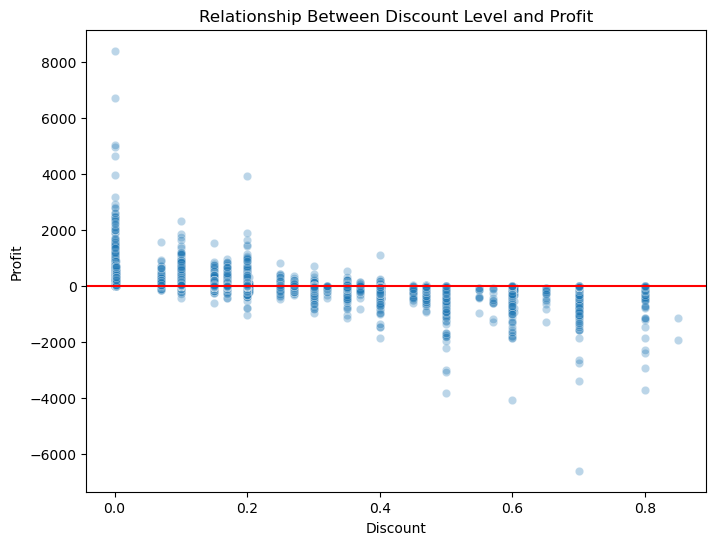

In [28]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Discount", y="Profit", alpha=0.3)

plt.axhline(0, color="red")
plt.title("Relationship Between Discount Level and Profit")
plt.show()

In [19]:
def profit_with_discount_cap(cap):
    return df[df["Discount"] <= cap]["Profit"].sum()

caps = [0.1, 0.2, 0.3, 0.4, 0.5]

for cap in caps:
    print(f"Max discount {cap*100:.0f}% -> Profit: {profit_with_discount_cap(cap):,.0f}")

Max discount 10% -> Profit: 2,108,885
Max discount 20% -> Profit: 2,282,139
Max discount 30% -> Profit: 2,260,984
Max discount 40% -> Profit: 2,094,868
Max discount 50% -> Profit: 1,880,039


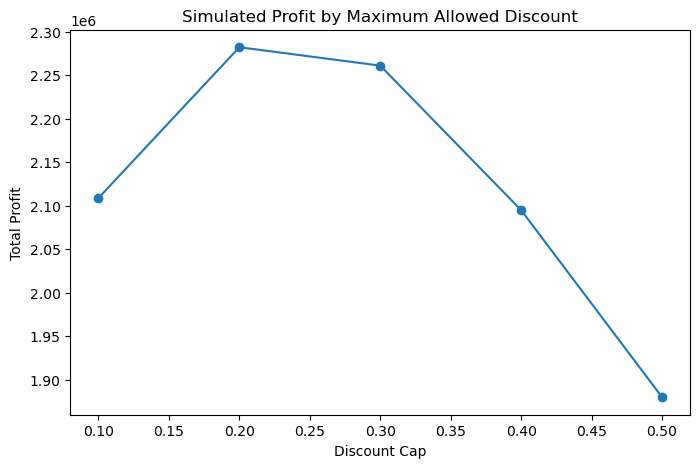

In [29]:
caps = [0.1, 0.2, 0.3, 0.4, 0.5]
profits = [profit_with_discount_cap(c) for c in caps]

plt.figure(figsize=(8,5))
plt.plot(caps, profits, marker="o")

plt.title("Simulated Profit by Maximum Allowed Discount")
plt.xlabel("Discount Cap")
plt.ylabel("Total Profit")

plt.show()

In [24]:
scenario_df = pd.DataFrame({
    "Discount_Cap": caps,
    "Simulated_Profit": profits
})

scenario_df["Discount_Cap_Pct"] = scenario_df["Discount_Cap"] * 100
scenario_df["Profit_Change_vs_50pct"] = scenario_df["Simulated_Profit"] - scenario_df.loc[scenario_df["Discount_Cap"] == 0.5, "Simulated_Profit"].values[0]

scenario_df

,Discount_Cap,Simulated_Profit,Discount_Cap_Pct,Profit_Change_vs_50pct
0,0.1000,"2,108,884.5346",10.0000,"228,845.5855"
1,0.2000,"2,282,139.3780",20.0000,"402,100.4289"
2,0.3000,"2,260,983.7649",30.0000,"380,944.8158"
3,0.4000,"2,094,868.3162",40.0000,"214,829.3671"
4,0.5000,"1,880,038.9490",50.0000,0.0000


In [27]:
category_summary = df.groupby("Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Avg_Discount=("Discount", "mean"),
    Category_Profit_Margin=("Profit", lambda x: x.sum() / df.loc[x.index, "Sales"].sum())
).reset_index()

category_summary

,Category,Total_Sales,Total_Profit,Avg_Discount,Category_Profit_Margin
0,Furniture,4110884,"285,204.7238",0.1681,0.0694
1,Office Supplies,3787330,"518,473.8343",0.1374,0.1369
2,Technology,4744691,"663,778.7332",0.1353,0.1399


In [26]:
import statsmodels.api as sm

X = df[["Discount", "Sales", "Shipping.Cost", "Quantity"]]
y = df["Profit"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Profit   R-squared:                       0.314
Model:                            OLS   Adj. R-squared:                  0.314
Method:                 Least Squares   F-statistic:                     5877.
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:00:11   Log-Likelihood:            -3.2781e+05
No. Observations:               51290   AIC:                         6.556e+05
Df Residuals:                   51285   BIC:                         6.557e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            32.7413      1.248     26.233

## Key Findings

- The dataset contains 51,290 orders, of which 12,544 are loss-making.
- Nearly 24.5% of all orders generate negative profit.
- Profit is maximised when discounts are capped at around 20%.
- Compared with allowing discounts up to 50%, a 20% discount cap could increase profit by approximately 402,100.
- Furniture is the most vulnerable category under the current discount strategy.
- Regression results confirm that higher discount levels are significantly associated with lower profitability.